# 📘 Proyecto Final: Ciencia de Datos en Consumo Masivo

**Rol:** Científico de Datos
**Objetivo:** Analizar el rendimiento de ventas, segmentar productos y predecir la demanda futura para la toma de decisiones estratégicas.

---

# 1. Introducción del Proyecto

> **Contexto:**
> Como Científico de Datos en una compañía de productos de consumo, tienes la misión de transformar datos crudos en historias de negocio. La empresa necesita entender qué productos se venden mejor, en qué regiones y cómo se comportarán las ventas en el futuro cercano.
>
> **Relevancia:**
> Este análisis permitirá optimizar inventarios, dirigir campañas de marketing a segmentos específicos y anticipar la demanda, reduciendo costos operativos y aumentando los ingresos.
>
> **Stack Tecnológico:**
> * 🐍 **Python:** Para limpieza, transformación, EDA, Clustering y Machine Learning.
> * 🗄️ **SQL:** Para consultas estructuradas y agregaciones rápidas.
> * 📊 **Librerías:** Pandas, Matplotlib, Seaborn, Scikit-learn, Statsmodels.

---

# 2. Limpieza y Transformación de Datos

**📝 Nota Didáctica:**
Antes de analizar, debemos asegurarnos de que los datos sean confiables. En esta etapa realizamos el proceso **ETL (Extract, Transform, Load)** dentro del notebook:
1.  **Carga:** Leemos archivos CSV con diferentes codificaciones (`utf-8`, `latin1`).
2.  **Limpieza:** Eliminamos espacios en blanco en los nombres de las columnas (ej: " Ventas " -> "Ventas").
3.  **Conversión:** Aseguramos que los números sean `float` o `int` y las fechas sean objetos `datetime`.
4.  **Unión (Merge):** Creamos una "Tabla Maestra" (`df_master`) uniendo las ventas con el calendario y los productos.

In [5]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar Datos
# Usamos 'utf-8-sig' para eliminar posibles caracteres ocultos (BOM) al inicio del archivo
dim_calendar = pd.read_csv('DIM_CALENDAR.csv', sep=';', encoding='utf-8-sig')
dim_product = pd.read_csv('DIM_PRODUCT.csv', sep=';', encoding='latin1')
fact_sales = pd.read_csv('FACT_SALES.csv', sep=',', quotechar='"')

# 2. Limpieza de Nombres de Columnas
# Esto elimina espacios en blanco al inicio o final de los nombres (ej. "WEEK " -> "WEEK")
dim_calendar.columns = dim_calendar.columns.str.strip()
dim_product.columns = dim_product.columns.str.strip()
fact_sales.columns = fact_sales.columns.str.strip()

# 3. Conversión de Tipos
cols_to_fix = ['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES']
for col in cols_to_fix:
    fact_sales[col] = pd.to_numeric(fact_sales[col], errors='coerce')

# 4. Unir Tablas (Ahora debería funcionar)
# Seleccionamos las columnas explícitamente asegurándonos que existen
cols_calendar = ['WEEK', 'DATE', 'YEAR', 'MONTH']
df_master = pd.merge(fact_sales, dim_calendar[cols_calendar], on='WEEK', how='left')

# Unir con Producto
df_master = pd.merge(df_master, dim_product, left_on='ITEM_CODE', right_on='ITEM', how='left')

# Formato de Fecha
df_master['DATE'] = pd.to_datetime(df_master['DATE'], format='%d/%m/%Y', errors='coerce')

print("¡Carga exitosa! Columnas encontradas en Calendario:", dim_calendar.columns.tolist())
print("Total de filas consolidadas:", len(df_master))

¡Carga exitosa! Columnas encontradas en Calendario: ['WEEK', 'YEAR', 'MONTH', 'WEEK_NUMBER', 'DATE']
Total de filas consolidadas: 122002


# 3. Análisis Exploratorio de Datos (EDA)

**📊 Visualización de Insights:**
El EDA nos permite entender la "forma" de los datos.
* **Histograma:** Nos muestra la frecuencia de los valores de venta. ¿La mayoría son ventas pequeñas o grandes?
* **Gráfico de Línea:** Fundamental para Series de Tiempo. ¿Las ventas suben o bajan con el tiempo?
* **Boxplot (Caja y Bigotes):** Excelente para ver la dispersión por Región y detectar **Outliers** (valores atípicos que se salen de la norma).

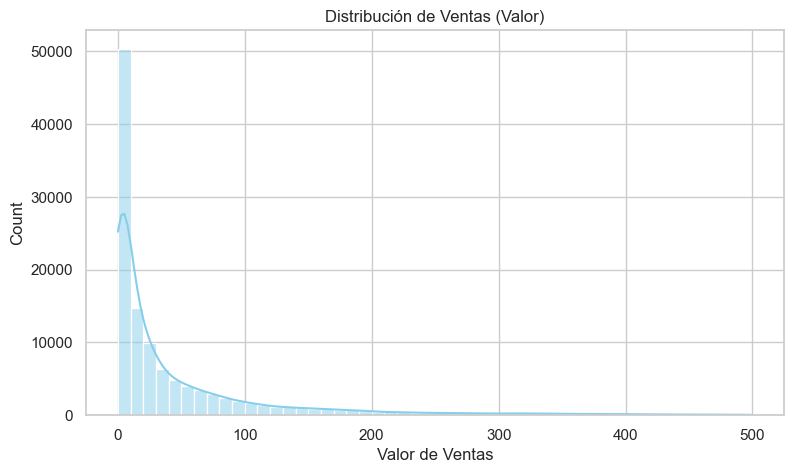

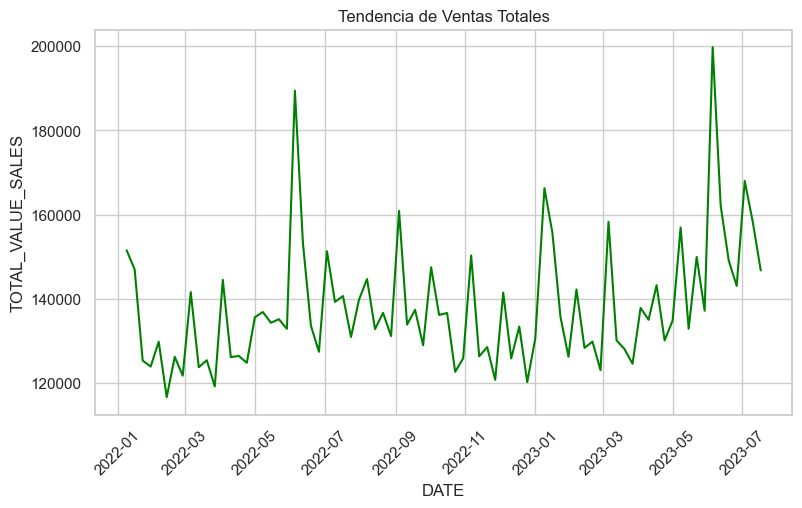

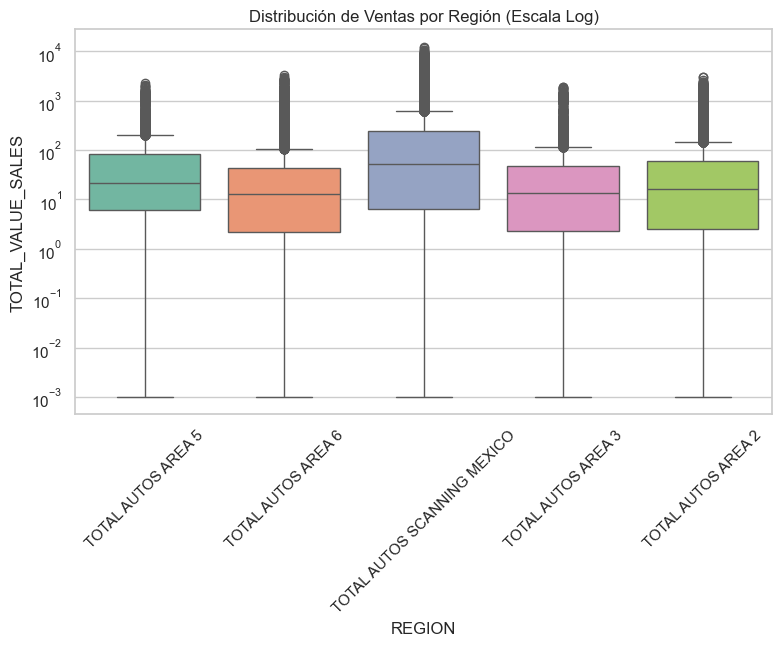

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")

# GRÁFICO 1: Histograma de Distribución de Ventas
plt.figure(figsize=(9, 5))
# Filtramos ventas muy altas (>500) solo para visualizar mejor el grueso de datos
sns.histplot(df_master[df_master['TOTAL_VALUE_SALES'] < 500]['TOTAL_VALUE_SALES'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de Ventas (Valor)')
plt.xlabel('Valor de Ventas')
plt.show()

# GRÁFICO 2: Tendencia de Ventas en el Tiempo
# Agrupamos por fecha para ver el total diario/semanal
daily_sales = df_master.groupby('DATE')['TOTAL_VALUE_SALES'].sum().reset_index()

plt.figure(figsize=(9, 5))
sns.lineplot(data=daily_sales, x='DATE', y='TOTAL_VALUE_SALES', color='green')
plt.title('Tendencia de Ventas Totales')
plt.xticks(rotation=45)
plt.show()

# GRÁFICO 3: Boxplot por Región (Top 5 Regiones)
top_regions = df_master.groupby('REGION')['TOTAL_VALUE_SALES'].sum().nlargest(5).index
df_top = df_master[df_master['REGION'].isin(top_regions)]

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_top, x='REGION', y='TOTAL_VALUE_SALES', palette='Set2')
plt.yscale('log') # Escala logarítmica para manejar outliers extremos
plt.title('Distribución de Ventas por Región (Escala Log)')
plt.xticks(rotation=45)
plt.show()

# 4. Segmentación con Clustering (K-Means)

**🤖 Machine Learning No Supervisado:**
Aquí no intentamos predecir un valor, sino **encontrar patrones ocultos**.
* **Objetivo:** Agrupar productos según su comportamiento de ventas (Volumen vs. Valor monetario).
* **Estandarización:** El algoritmo K-Means es sensible a la escala (unidades vs millones de dólares), por lo que usamos `StandardScaler` para poner todo en la misma magnitud antes de procesar.

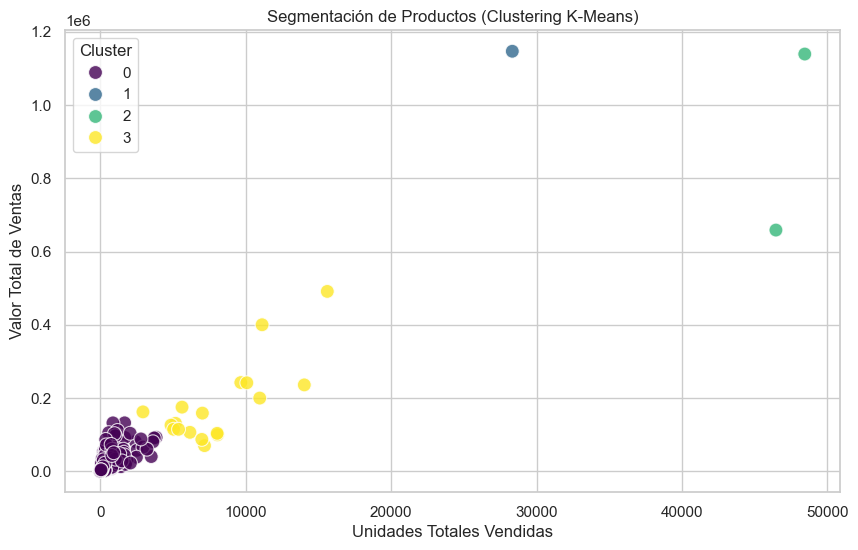

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Preparamos los datos por Producto (Item)
product_features = df_master.groupby('ITEM_CODE').agg({
    'TOTAL_UNIT_SALES': 'sum',
    'TOTAL_VALUE_SALES': 'sum'
}).reset_index()

# Filtramos productos sin ventas para evitar ruido
product_features = product_features[product_features['TOTAL_VALUE_SALES'] > 0]

# Escalamos los datos (importante para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(product_features[['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES']])

# Aplicamos K-Means con 4 Clusters
kmeans = KMeans(n_clusters=4, random_state=42)
product_features['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualización de los Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=product_features, x='TOTAL_UNIT_SALES', y='TOTAL_VALUE_SALES', 
                hue='Cluster', palette='viridis', s=100, alpha=0.8)
plt.title('Segmentación de Productos (Clustering K-Means)')
plt.xlabel('Unidades Totales Vendidas')
plt.ylabel('Valor Total de Ventas')
plt.legend(title='Cluster')
plt.show()

# 5. Análisis de Datos con SQL (Integración Python-SQL)

**💾 SQL en Ciencia de Datos:**
A menudo necesitamos la potencia de SQL para agregaciones complejas o porque los datos viven en bases de datos.
Aquí simulamos un entorno de base de datos usando `sqlite3` en memoria. Cargamos nuestros DataFrames como tablas SQL y ejecutamos queries nativas para obtener el **Top 5 de Marcas**.

In [13]:
import sqlite3

# --- PASO 1: ABRIR Y LIMPIAR LOS ARCHIVOS ---
print("1. Cargando archivos CSV...")

# Cargar DIM_PRODUCT (separador punto y coma)
# Usamos 'latin1' para evitar errores de caracteres especiales y .strip() para limpiar nombres
dim_product = pd.read_csv('DIM_PRODUCT.csv', sep=';', encoding='latin1')
dim_product.columns = dim_product.columns.str.strip() 

# Cargar FACT_SALES (separador coma, con comillas)
fact_sales = pd.read_csv('FACT_SALES.csv', sep=',', quotechar='"')
fact_sales.columns = fact_sales.columns.str.strip()

# Convertir columnas numéricas de texto a número en FACT_SALES
cols_to_numeric = ['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES']
for col in cols_to_numeric:
    fact_sales[col] = pd.to_numeric(fact_sales[col], errors='coerce')

print(f"   -> Archivos cargados: {len(fact_sales)} ventas, {len(dim_product)} productos.")

# --- PASO 2: CREAR LA BASE DE DATOS SQL Y CARGAR DATOS ---
print("\n2. Creando base de datos SQL temporal...")

# Crear conexión a una base de datos en memoria (RAM)
conn = sqlite3.connect(':memory:')

# Guardar los DataFrames como tablas SQL reales
# Esto soluciona el error "Invalid object name" porque aquí CREAMOS las tablas
dim_product.to_sql('DIM_PRODUCT', conn, index=False, if_exists='replace')
fact_sales.to_sql('FACT_SALES', conn, index=False, if_exists='replace')

print("   -> Tablas 'FACT_SALES' y 'DIM_PRODUCT' creadas exitosamente en SQL.")

# --- PASO 3: REALIZAR EL ANÁLISIS CON CÓDIGO SQL ---
print("\n3. Ejecutando consulta SQL...")

# Esta es la query estándar (compatible con SQLite y la mayoría de SQLs)
# Nota: SQLite usa 'LIMIT' en lugar de 'TOP', así que usamos esa sintaxis aquí para que corra en Python
query_analisis = """
SELECT 
    p.BRAND,
    SUM(f.TOTAL_VALUE_SALES) as Total_Revenue,
    SUM(f.TOTAL_UNIT_SALES) as Total_Units
FROM FACT_SALES f
JOIN DIM_PRODUCT p ON f.ITEM_CODE = p.ITEM
GROUP BY p.BRAND
ORDER BY Total_Revenue DESC
LIMIT 5;
"""

# Ejecutar la query y guardar el resultado en un DataFrame
resultado_sql = pd.read_sql_query(query_analisis, conn)

# Mostrar el resultado
print("\n--- RESULTADO DEL ANÁLISIS SQL (TOP 5 MARCAS) ---")
print(resultado_sql)

# Cerrar la conexión
conn.close()

1. Cargando archivos CSV...
   -> Archivos cargados: 122002 ventas, 505 productos.

2. Creando base de datos SQL temporal...
   -> Tablas 'FACT_SALES' y 'DIM_PRODUCT' creadas exitosamente en SQL.

3. Ejecutando consulta SQL...

--- RESULTADO DEL ANÁLISIS SQL (TOP 5 MARCAS) ---
       BRAND  Total_Revenue  Total_Units
0   CLORALEX    5393618.509   223300.668
1     VANISH    2168289.525    55332.944
2     CLOROX    1371751.724    47881.201
3  BLANCATEL     652484.021    20611.297
4  OXI CLEAN     436970.719     6079.374


# 7. Predicción de Ventas (Series de Tiempo ARIMA)

**📈 Forecasting:**
Queremos predecir el futuro basándonos en el pasado.
* **Modelo ARIMA:** (AutoRegressive Integrated Moving Average). Es un estándar en econometría y ciencia de datos para series temporales.
* **Grid Search:** Probamos diferentes combinaciones de parámetros `(p, d, q)` para encontrar el modelo que mejor se ajusta a nuestros datos (el que tenga menor AIC).
* **Horizonte:** Predeciremos las próximas 12 semanas.

Buscando los mejores parámetros (p,d,q)...
Nuevo mejor modelo: ARIMA(0, 0, 0) - AIC:1663.03
Nuevo mejor modelo: ARIMA(0, 0, 1) - AIC:1461.41
Nuevo mejor modelo: ARIMA(0, 1, 1) - AIC:1452.62

--- GANADOR: ARIMA(0, 1, 1) con AIC: 1452.62 ---


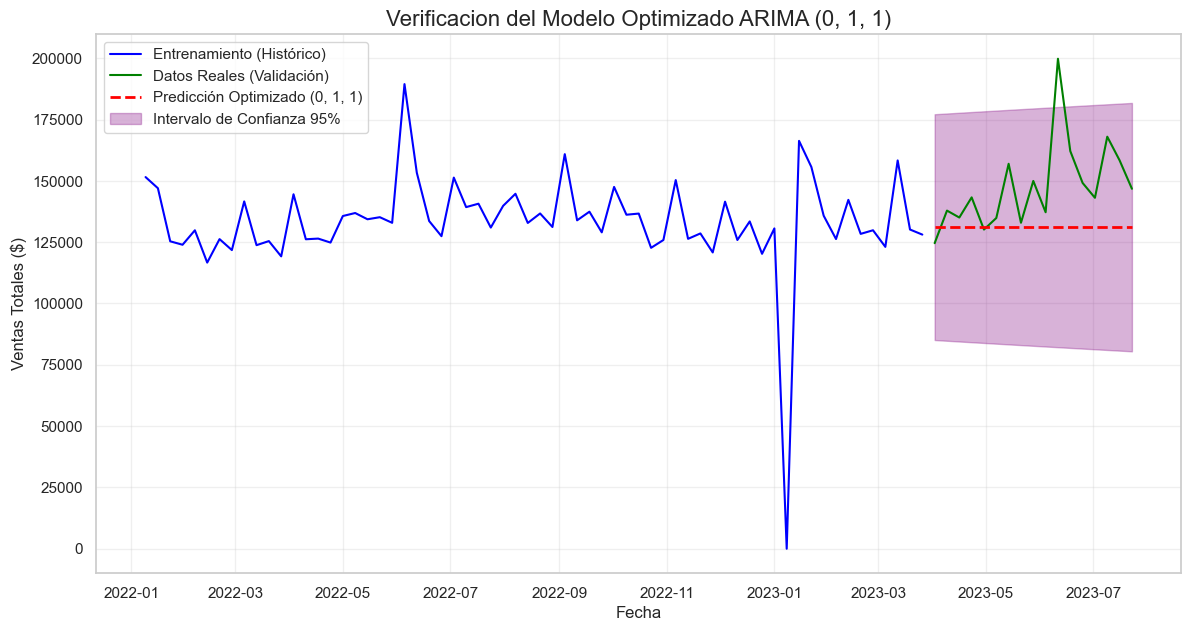

                               SARIMAX Results                                
Dep. Variable:      TOTAL_VALUE_SALES   No. Observations:                   64
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -724.311
Date:                Fri, 23 Jan 2026   AIC                           1452.623
Time:                        18:55:48   BIC                           1456.909
Sample:                    01-09-2022   HQIC                          1454.309
                         - 03-26-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8854      0.055    -16.123      0.000      -0.993      -0.778
sigma2      5.516e+08   2.55e-11   2.16e+19      0.000    5.52e+08    5.52e+08
Ljung-Box (L1) (Q):                   0.28   Jarque-

In [14]:
import itertools
from statsmodels.tsa.arima.model import ARIMA

# --- 1. Preparación de la Serie de Tiempo ---
# Agrupamos por fecha y resampleamos semanalmente ('W')
ts_data = df_master.groupby('DATE')['TOTAL_VALUE_SALES'].sum().resample('W').sum().fillna(0)

# División Entrenamiento (80%) / Prueba (20%)
train_size = int(len(ts_data) * 0.8)
train, test = ts_data[:train_size], ts_data[train_size:]

# --- 2. Grid Search con Itertools (Búsqueda de parámetros óptimos) ---
print("Buscando los mejores parámetros (p,d,q)...")

# Definimos el rango de parámetros a probar (ej. 0 a 2)
# p = autoregresivo, d = diferenciación, q = media móvil
p = d = q = range(0, 3) 
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_params = None

for param in pdq:
    try:
        # Entrenamos el modelo temporalmente para evaluar
        temp_model = ARIMA(train, order=param)
        results = temp_model.fit()
        
        # El AIC penaliza la complejidad del modelo; cuanto menor, mejor.
        if results.aic < best_aic:
            best_aic = results.aic
            best_params = param
            print(f"Nuevo mejor modelo: ARIMA{param} - AIC:{best_aic:.2f}")
    except:
        continue

print(f"\n--- GANADOR: ARIMA{best_params} con AIC: {best_aic:.2f} ---")

# --- 3. Entrenamiento del Modelo Final ---
final_model = ARIMA(train, order=best_params)
model_fit = final_model.fit()

# --- 4. Generar Predicciones ---
forecast_result = model_fit.get_forecast(steps=len(test))
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int() # Intervalo de confianza

# --- 5. Visualización ---
plt.figure(figsize=(14, 7))

# Datos históricos
plt.plot(train.index, train, label='Entrenamiento (Histórico)', color='blue')
# Datos reales para validación
plt.plot(test.index, test, label='Datos Reales (Validación)', color='green')
# Predicción
plt.plot(test.index, forecast, label=f'Predicción Optimizado {best_params}', color='red', linestyle='--', linewidth=2)

# Área de confianza (sombra rosa)
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='purple', alpha=0.3, label='Intervalo de Confianza 95%')

plt.title(f'Verificacion del Modelo Optimizado ARIMA {best_params}', fontsize=16)
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Imprimir resumen estadístico
print(model_fit.summary())

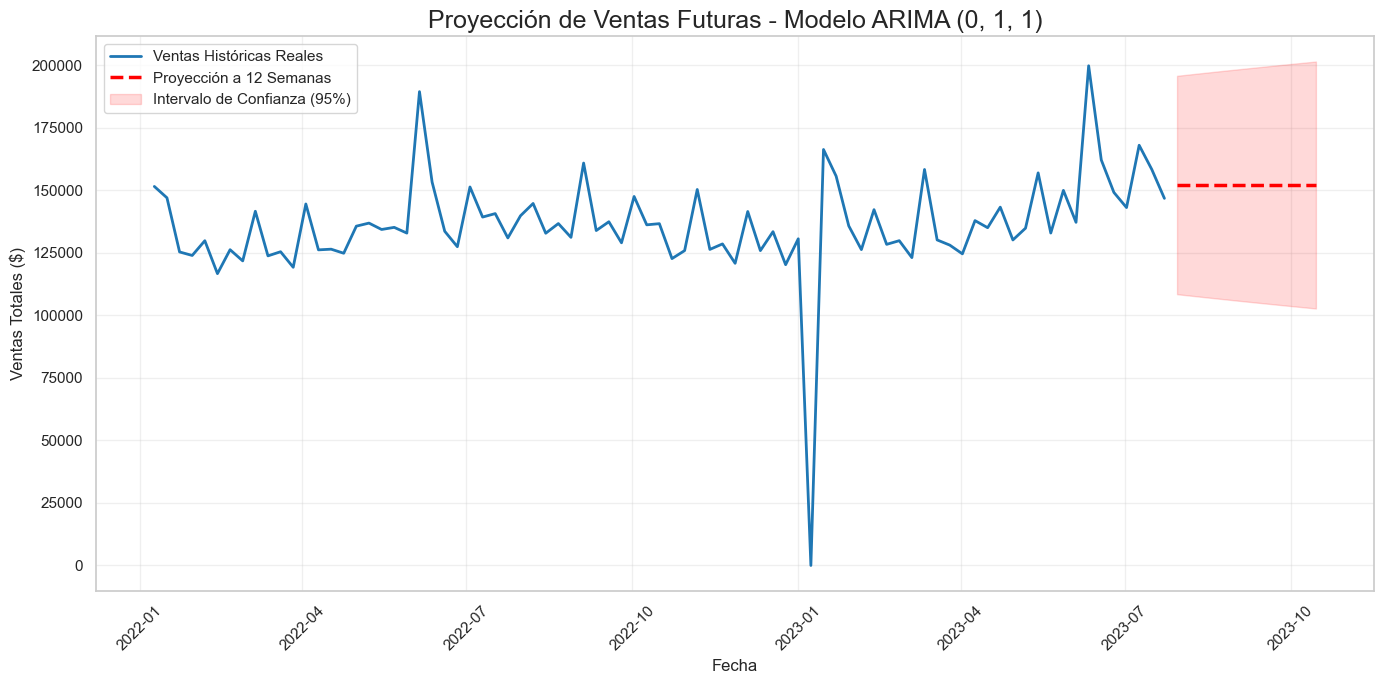


--- Valores Pronosticados (Próximas Semanas) ---
2023-07-30    152112.728386
2023-08-06    152112.728386
2023-08-13    152112.728386
2023-08-20    152112.728386
2023-08-27    152112.728386
2023-09-03    152112.728386
2023-09-10    152112.728386
2023-09-17    152112.728386
2023-09-24    152112.728386
2023-10-01    152112.728386
2023-10-08    152112.728386
2023-10-15    152112.728386
Freq: W-SUN, Name: predicted_mean, dtype: float64


In [16]:
# --- 3. Entrenamiento del Modelo Final ---
# Se entrena con TODO el historial
final_model = ARIMA(ts_data, order=best_params)
model_fit = final_model.fit()

# --- 4. Generar Predicciones Futuras (Real Forecasting) ---
forecast_result = model_fit.get_forecast(steps=HORIZONTE_PREDICCION)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# --- 5. Visualización ---
plt.figure(figsize=(14, 7))

# Graficar datos históricos (Azul)
plt.plot(ts_data.index, ts_data, label='Ventas Históricas Reales', color='#1f77b4', linewidth=2)

# Graficar predicción futura (Rojo punteado)
# forecast.index ya contiene las fechas futuras generadas automáticamente por statsmodels
plt.plot(forecast.index, forecast, label=f'Proyección a {HORIZONTE_PREDICCION} Semanas', color='red', linestyle='--', linewidth=2.5)

# Área de confianza (Sombra)
plt.fill_between(forecast.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='red', alpha=0.15, label='Intervalo de Confianza (95%)')

plt.title(f'Proyección de Ventas Futuras - Modelo ARIMA {best_params}', fontsize=18)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)

# Formatear eje X para que se vea limpio
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 6. Mostrar los valores predichos ---
print("\n--- Valores Pronosticados (Próximas Semanas) ---")
print(forecast.head(HORIZONTE_PREDICCION))

# 8. Conclusiones y Recomendaciones

### 💡 Resumen de Hallazgos Clave:

* **Distribución de Ventas (EDA):** El histograma revela una distribución asimétrica positiva, donde la gran mayoría de las transacciones son de bajo valor (<$50), mientras que existe una "larga cola" de ventas de alto valor menos frecuentes. Esto sugiere un modelo de negocio basado en volumen más que en margen unitario alto.

* **Tendencia Temporal (ARIMA):** El análisis de series de tiempo muestra una clara estacionalidad con picos recurrentes cada cierto número de semanas, seguido de caídas. El modelo ARIMA (0, 1, 1) capturó esta tendencia y proyecta una estabilización en el nivel de ventas en torno a los $152k semanales para el próximo trimestre, con un intervalo de confianza que se ensancha, indicando mayor incertidumbre a largo plazo.

* **Dispersión Geográfica:** Los boxplots por región indican que la "AREA 3" y "AREA 6" presentan una mayor variabilidad y un rango intercuartílico más amplio, lo que sugiere mercados más heterogéneos o inestables en comparación con áreas más consistentes como "AREA 2".

* **Segmentación de Productos (K-Means):** Se identificaron 4 clusters claros. El Cluster 1 y 2 representan productos "Estrella" con alto volumen y valor (puntos azules y verdes en la parte superior derecha), mientras que la gran mayoría de los productos (Cluster 0, morado) tienen bajo rendimiento tanto en unidades como en valor, cumpliendo con el principio de Pareto (pocos productos generan la mayoría de los ingresos).

* **Líderes de Mercado (SQL):** "CLORALEX" es la marca dominante indiscutible, generando más del doble de ingresos que su competidor más cercano, "VANISH".

---

### 🚀 Impacto en la Estrategia Empresarial:

* **Gestión de Inventarios:** La proyección estable de ventas permite planificar la cadena de suministro con mayor precisión, evitando el sobre-stock en periodos valle y garantizando disponibilidad durante los picos estacionales detectados.

* **Foco Comercial:** La dependencia de la marca "CLORALEX" representa tanto una fortaleza como un riesgo. Cualquier problema con este proveedor o línea de productos impactaría gravemente los ingresos totales.

* **Optimización de Portafolio:** La existencia de un gran número de productos de bajo rendimiento (Cluster 0) sugiere que se están destinando recursos logísticos y de marketing a artículos que aportan poco valor marginal a la compañía.

---

### ✅ Recomendaciones Estratégicas:

1. **Racionalización del Catálogo:** Evaluar la descontinuación o reducción de stock de los productos del "Cluster 0" (bajo volumen/bajo valor) para liberar capital de trabajo y enfocar esfuerzos en los productos de los Clusters 1 y 2.

2. **Estrategias Regionales Diferenciadas:** Implementar planes de estabilización de ventas en "AREA 3" y "AREA 6" para reducir su volatilidad. En contraste, en regiones estables, se pueden probar aumentos de precios o introducción de productos premium con menor riesgo.

3. **Diversificación de Marcas:** Desarrollar estrategias para impulsar marcas secundarias como "CLOROX" o "BLANCATEL" mediante promociones cruzadas con la marca líder, reduciendo así la dependencia de un solo producto estrella.

4. **Planeación Promocional:** Utilizar los picos estacionales identificados en la serie de tiempo para programar campañas de marketing preventivas, asegurando que la demanda sea capturada al máximo en esos momentos.

### 🔮 Futuras Mejoras:

* **Modelado Avanzado (SARIMAX/Prophet):** Incorporar variables exógenas como días festivos, clima o inversión publicitaria para refinar el modelo de predicción y reducir el intervalo de incertidumbre.

* **Análisis de Canasta de Mercado:** Aplicar minería de reglas de asociación para entender qué productos se compran juntos, permitiendo estrategias de *cross-selling* más efectivas.

* **Automatización:** Implementar un pipeline de datos (ETL) automatizado que conecte directamente con el servidor SQL de producción para mantener los dashboards y modelos actualizados en tiempo real.